2025-02-28 20:28:54.678756: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
2025-02-28 20:29:18.903164: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


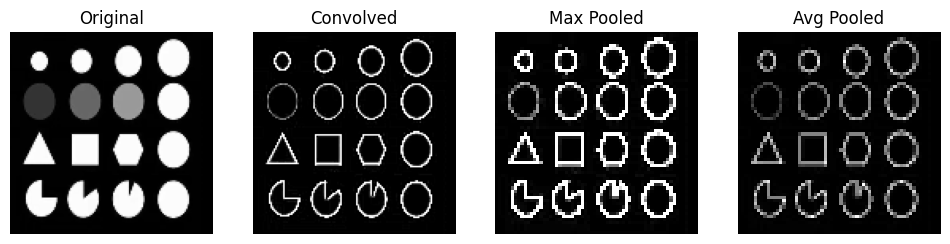

In [1]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

image_path = "/Users/stefenkaushik/testImg.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image = cv2.resize(image, (128, 128))  

kernel = np.array([[-1, -1, -1], 
                   [-1,  8, -1], 
                   [-1, -1, -1]])

convolved_image = cv2.filter2D(image, -1, kernel)

def max_pooling(img, pool_size=2):
    h, w = img.shape
    new_h, new_w = h // pool_size, w // pool_size
    pooled_img = np.zeros((new_h, new_w))

    for i in range(new_h):
        for j in range(new_w):
            pooled_img[i, j] = np.max(img[i * pool_size:(i + 1) * pool_size, j * pool_size:(j + 1) * pool_size])
    
    return pooled_img

max_pooled = max_pooling(convolved_image)

avg_pooled = cv2.resize(convolved_image, (64, 64), interpolation=cv2.INTER_AREA)

image_tensor = tf.convert_to_tensor(convolved_image, dtype=tf.float32)
image_tensor = tf.expand_dims(tf.expand_dims(image_tensor, axis=0), axis=-1)  
depthwise_pooled = tf.nn.pool(image_tensor, window_shape=[2, 2], pooling_type='MAX', strides=[2, 2])
depthwise_pooled = tf.squeeze(depthwise_pooled).numpy()  

fig, axes = plt.subplots(1, 4, figsize=(12, 6))
titles = ["Original", "Convolved", "Max Pooled", "Avg Pooled"]
images = [image, convolved_image, max_pooled, avg_pooled]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.show()


Epoch 1/5
1875/1875 [==============================] - 27s 13ms/step - loss: 0.4714 - accuracy: 0.8287 - val_loss: 0.4174 - val_accuracy: 0.8459
Epoch 2/5
1875/1875 [==============================] - 29s 16ms/step - loss: 0.3563 - accuracy: 0.8687 - val_loss: 0.4076 - val_accuracy: 0.8544
Epoch 3/5
1875/1875 [==============================] - 29s 15ms/step - loss: 0.3238 - accuracy: 0.8799 - val_loss: 0.3848 - val_accuracy: 0.8629
Epoch 4/5
1875/1875 [==============================] - 31s 17ms/step - loss: 0.2983 - accuracy: 0.8899 - val_loss: 0.3536 - val_accuracy: 0.8731
Epoch 5/5
1875/1875 [==============================] - 29s 16ms/step - loss: 0.2800 - accuracy: 0.8963 - val_loss: 0.3279 - val_accuracy: 0.8835
Epoch 1/5
1875/1875 [==============================] - 27s 14ms/step - loss: 0.2650 - accuracy: 0.8998 - val_loss: 0.3390 - val_accuracy: 0.8840
Epoch 2/5
1875/1875 [==============================] - 32s 17ms/step - loss: 0.2521 - accuracy: 0.9049 - val_loss: 0.3202 - val_ac

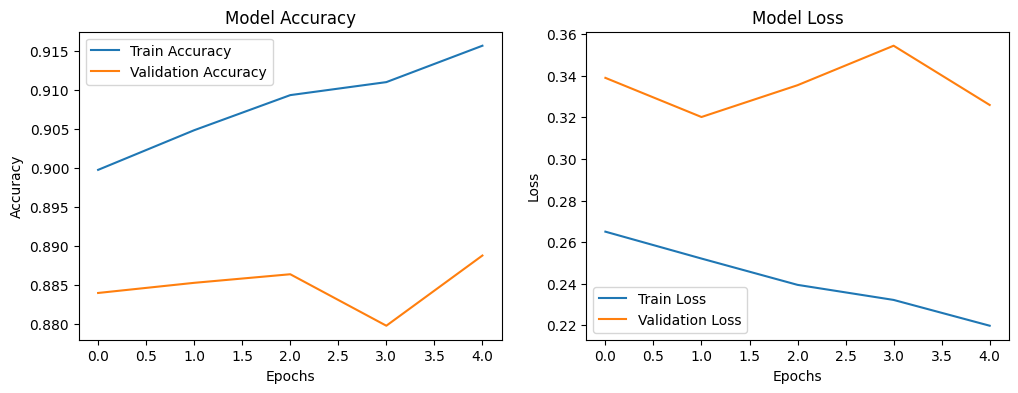

313/313 [==============================] - 2s 5ms/step


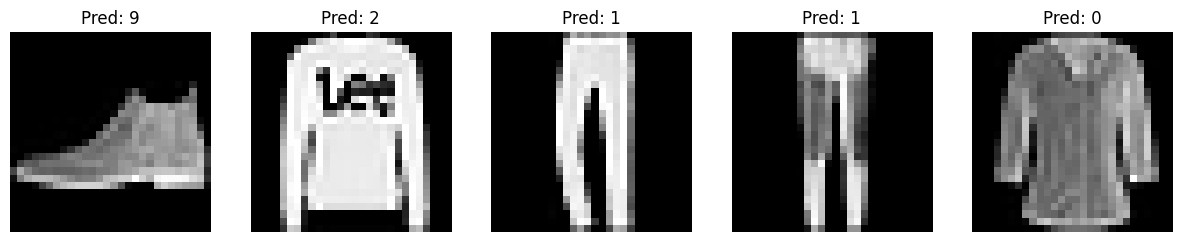

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0  

x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

fcn_model = keras.Sequential([
    layers.Dense(512, activation="relu", input_shape=(28*28,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax")
])

fcn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
fcn_model.fit(x_train_flat, y_train, epochs=5, validation_data=(x_test_flat, y_test))
history = fcn_model.fit(x_train_flat, y_train, epochs=5, validation_data=(x_test_flat, y_test))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Model Loss')

plt.show()

predictions = fcn_model.predict(x_test_flat)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(x_test[i], cmap='gray')
    ax.set_title(f'Pred: {np.argmax(predictions[i])}')
    ax.axis('off')
plt.show()


In [3]:

cnn_model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.fit(x_train[..., np.newaxis], y_train, epochs=5, validation_data=(x_test[..., np.newaxis], y_test))


Epoch 1/5
1875/1875 [==============================] - 104s 54ms/step - loss: 0.4482 - accuracy: 0.8357 - val_loss: 0.3407 - val_accuracy: 0.8805
Epoch 2/5
1875/1875 [==============================] - 99s 53ms/step - loss: 0.2993 - accuracy: 0.8908 - val_loss: 0.3100 - val_accuracy: 0.8869
Epoch 3/5
1875/1875 [==============================] - 91s 49ms/step - loss: 0.2540 - accuracy: 0.9064 - val_loss: 0.2996 - val_accuracy: 0.8934
Epoch 4/5
1875/1875 [==============================] - 86s 46ms/step - loss: 0.2205 - accuracy: 0.9180 - val_loss: 0.2703 - val_accuracy: 0.9030
Epoch 5/5
1875/1875 [==============================] - 75s 40ms/step - loss: 0.1935 - accuracy: 0.9288 - val_loss: 0.2624 - val_accuracy: 0.9048


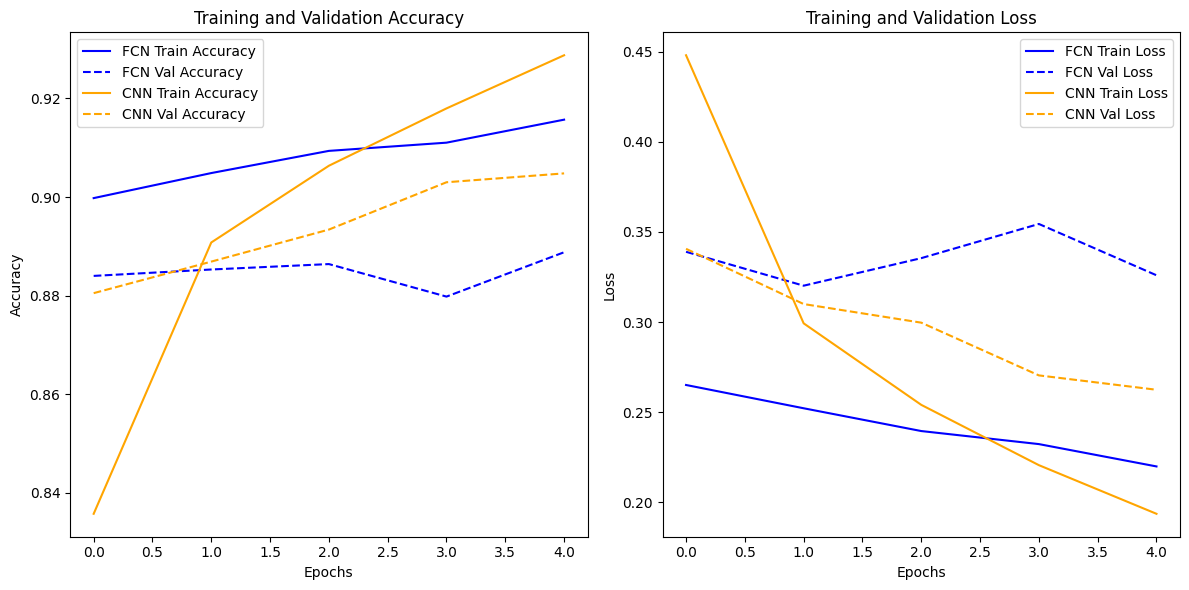

In [4]:
import matplotlib.pyplot as plt

fcn_history = {
    'train_acc': history.history['accuracy'],
    'val_acc': history.history['val_accuracy'],
    'train_loss': history.history['loss'],
    'val_loss': history.history['val_loss']
}

cnn_history = cnn_model.history.history

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(fcn_history['train_acc'], label='FCN Train Accuracy', color='blue')
plt.plot(fcn_history['val_acc'], label='FCN Val Accuracy', color='blue', linestyle='dashed')
plt.plot(cnn_history['accuracy'], label='CNN Train Accuracy', color='orange')
plt.plot(cnn_history['val_accuracy'], label='CNN Val Accuracy', color='orange', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(fcn_history['train_loss'], label='FCN Train Loss', color='blue')
plt.plot(fcn_history['val_loss'], label='FCN Val Loss', color='blue', linestyle='dashed')
plt.plot(cnn_history['loss'], label='CNN Train Loss', color='orange')
plt.plot(cnn_history['val_loss'], label='CNN Val Loss', color='orange', linestyle='dashed')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [5]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Input

base_model = ResNet50(weights=None, include_top=False, input_tensor=Input(shape=(224, 224, 3)))

x = Flatten()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dense(10, activation="softmax")(x)

resnet34_model = Model(inputs=base_model.input, outputs=x)

resnet34_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [6]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
train_ds, val_ds, test_ds = tfds.load("tf_flowers", 
                                      split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'], 
                                      as_supervised=True)

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224)) / 255.0
    return image, label

train_ds = train_ds.map(preprocess).batch(32).prefetch(1)
val_ds = val_ds.map(preprocess).batch(32).prefetch(1)
test_ds = test_ds.map(preprocess).batch(32).prefetch(1)

base_model = Xception(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  

x = base_model.output
x = GlobalAveragePooling2D()(x)  
x = Dense(256, activation="relu")(x)
x = Dense(5, activation="softmax")(x)  

xception_model = Model(inputs=base_model.input, outputs=x)


xception_model.compile(optimizer=Adam(learning_rate=0.001), 
                       loss="sparse_categorical_crossentropy", 
                       metrics=["accuracy"])
xception_model.fit(train_ds, validation_data=val_ds, epochs=5)


/Users/stefenkaushik/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Epoch 1/5
81/81 [==============================] - 728s 9s/step - loss: 0.5431 - accuracy: 0.8007 - val_loss: 0.2900 - val_accuracy: 0.8893
Epoch 2/5
81/81 [==============================] - 764s 9s/step - loss: 0.2698 - accuracy: 0.9066 - val_loss: 0.2693 - val_accuracy: 0.8984
Epoch 3/5
81/81 [==============================] - 813s 10s/step - loss: 0.1819 - accuracy: 0.9443 - val_loss: 0.2806 - val_accuracy: 0.8875
Epoch 4/5
81/81 [==============================] - 880s 11s/step - loss: 0.1267 - accuracy: 0.9634 - val_loss: 0.2812 - val_accuracy: 0.8929
Epoch 5/5
81/81 [==============================] - 887s 11s/step - loss: 0.1038 - accuracy: 0.9704 - val_loss: 0.2991 - val_accuracy: 0.8911


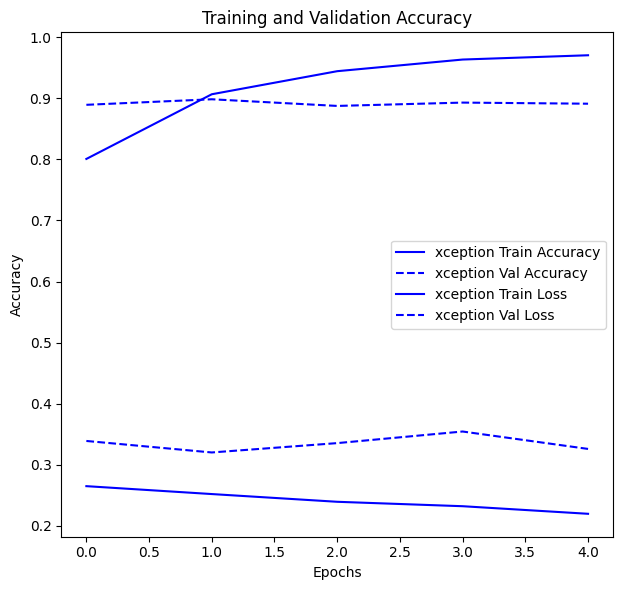

In [7]:

xception_history = {
    'train_acc': xception_model.history.history['accuracy'],
    'val_acc': xception_model.history.history['val_accuracy'],
    'train_loss': xception_model.history.history['loss'],
    'val_loss': xception_model.history.history['val_loss']
}
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(xception_history['train_acc'], label='xception Train Accuracy', color='blue')
plt.plot(xception_history['val_acc'], label='xception Val Accuracy', color='blue', linestyle='dashed')
plt.plot(fcn_history['train_loss'], label='xception Train Loss', color='blue')
plt.plot(fcn_history['val_loss'], label='xception Val Loss', color='blue', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()